# Tutorial 3d: Inspecting & Controlling a Run


This tutorial shows how to inspect an `OptimizationResult` in detail, attach observers
to monitor convergence, compose stopping criteria, and use a `CancelToken` for
programmatic early-stopping.

Topics covered:

- `OptimizationResult` fields
- `HistoryObserver` for per-iteration merit tracking
- `ConsoleObserver` and `disp` control
- `CheckpointObserver` for crash recovery
- Composable stopping criteria (`MaxIter`, `CostTolerance`, `|` operator)
- `CancelToken` for programmatic early-stopping
- Hard constraints via `add_constraint` and constraint diagnostics
  (`result.multipliers`, `result.active_set`, `result.constraint_report`)


In [1]:
import copy
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

from optiland import optic
from optiland.optimization import minimize, OptimizationProblem
from optiland.optimization.stopping.criteria import MaxIter, CostTolerance, GradNormTolerance
from optiland.optimization.observers.history import HistoryObserver
from optiland.optimization.observers.logging import ConsoleObserver
from optiland.optimization.observers.checkpoint import CheckpointObserver
from optiland.optimization.observers.cancel import CancelToken

## 1. Build a doublet lens and optimization problem

We start from a simple air-spaced doublet.  The same setup is reused (via `copy.deepcopy`)
in each section so that every experiment starts from the identical initial state.


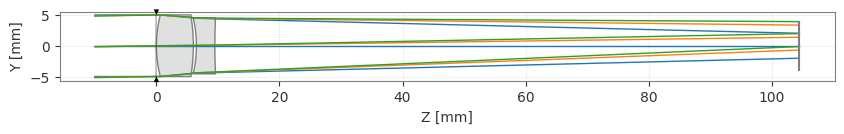

In [2]:
def build_doublet():
    """Return a fresh doublet Optic."""
    lens = optic.Optic()
    lens.surfaces.add(index=0, thickness=np.inf)
    lens.surfaces.add(index=1, thickness=6.0, radius=20.0, material='N-BK7', is_stop=True)
    lens.surfaces.add(index=2, thickness=0.5, radius=-30.0)
    lens.surfaces.add(index=3, thickness=3.0, radius=-20.0, material='N-SF5')
    lens.surfaces.add(index=4, thickness=95.0, radius=100.0)
    lens.surfaces.add(index=5)
    lens.set_aperture(aperture_type='EPD', value=10)
    lens.fields.set_type('angle')
    lens.fields.add(y=0.0)
    lens.fields.add(y=0.7)
    lens.fields.add(y=1.0)
    lens.wavelengths.add(value=0.4861)
    lens.wavelengths.add(value=0.5876, is_primary=True)
    lens.wavelengths.add(value=0.6563)
    return lens


def build_problem(lens):
    """Return an OptimizationProblem wired to *lens*."""
    problem = OptimizationProblem()
    for Hx, Hy in lens.fields.get_field_coords():
        input_data = {
            'optic': lens, 'surface_number': -1,
            'Hx': Hx, 'Hy': Hy,
            'num_rays': 3, 'wavelength': 0.5876,
            'distribution': 'hexapolar',
        }
        problem.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
    problem.add_operand('f2', target=100, weight=2, input_data={'optic': lens})
    for s in [1, 2, 3, 4]:
        problem.add_variable(lens, 'radius', surface_number=s, min_val=-500, max_val=500)
    problem.add_variable(lens, 'thickness', surface_number=4, min_val=50, max_val=200)
    return problem


lens_start = build_doublet()
_ = lens_start.draw()

## 2. OptimizationResult fields

Every call to `minimize()` returns an `OptimizationResult`.  The table below summarizes
the available attributes.

| Attribute | Type | Description |
|-----------|------|-------------|
| `value` | float | Final scalar merit function value |
| `x` | ndarray | Final parameter vector |
| `success` | bool | Whether the optimizer considered the run successful |
| `method` | str | Resolved algorithm name |
| `resolved_from` | str or None | `'auto'` when auto-selected, else `None` |
| `improvement_pct` | float | Percentage improvement from initial merit |
| `status` | str | Human-readable reason the run ended |
| `wall_time_s` | float | Elapsed wall-clock time in seconds |
| `history` | list or None | Per-iteration merits (requires `HistoryObserver`) |


In [3]:
lens1 = copy.deepcopy(lens_start)
problem1 = build_problem(lens1)

result = minimize(problem1, 'dls', disp=False)

print(f'Method:           {result.method}')
print(f'Resolved from:    {result.resolved_from}')
print(f'Merit:            {result.value:.6f}')
print(f'Improvement:      {result.improvement_pct:.1f}%')
print(f'Success:          {result.success}')
print(f'Stop reason:      {result.status}')
print(f'Wall time:        {result.wall_time_s:.3f}s')
print(f'Parameter vector: {result.x}')
print()
print(result)  # human-readable summary

Method:           dls
Resolved from:    None
Merit:            0.027358
Improvement:      100.0%
Success:          True
Stop reason:      cost_tol=1.00e-03 (rel_change=8.31e-06)
Wall time:        0.422s
Parameter vector: [-0.80680898 -1.28173803 -1.20684636  0.19216294  8.15187912]

OptimizationResult(x=array([-0.80680898, -1.28173803, -1.20684636,  0.19216294,  8.15187912]), success=True, status='cost_tol=1.00e-03 (rel_change=8.31e-06)', value=0.027358360096741648, initial_value=8567.271093662155, improvement_pct=99.99968066424188, iterations=9, n_value_evals=25, n_jac_evals=9, wall_time_s=0.42170290001377, history=None, backend='numpy', method='dls', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=27.76099906155984, lambda_final=3756.6886395195324, cond_estimate=5.447685049116995e+18)


## 3. HistoryObserver

`HistoryObserver` accumulates the merit value at each iteration.  After the run,
`observer.history` contains a list of floats that can be plotted to inspect convergence
behaviour.  Pass the observer via the `observers=` keyword argument to `minimize()`.


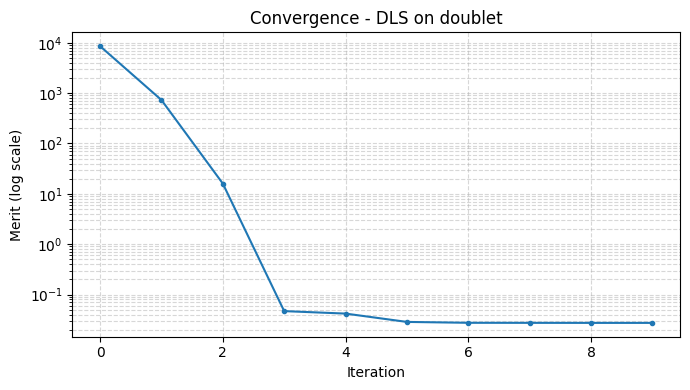

Total iterations recorded: 10
Initial merit: 8567.2711
Final merit:   0.0274


In [4]:
lens2 = copy.deepcopy(lens_start)
problem2 = build_problem(lens2)

observer = HistoryObserver()
result2 = minimize(problem2, 'dls', observers=[observer], disp=False)

plt.figure(figsize=(7, 4))
values = [r["value"] for r in result2.history]
plt.semilogy(values, marker='o', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Merit (log scale)')
plt.title('Convergence - DLS on doublet')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Total iterations recorded: {len(result2.history)}')
print(f'Initial merit: {result2.history[0]["value"]:.4f}')
print(f'Final merit:   {result2.history[-1]["value"]:.4f}')

## 4. ConsoleObserver and `disp` control

By default `minimize()` runs with `disp=True`, which internally attaches a
`ConsoleObserver` and prints a progress table to stdout.  Set `disp=False` to suppress
all output - useful in scripts, notebooks, or when you prefer to stream to a custom logger.

You can also construct a `ConsoleObserver` explicitly and pass it via `observers=` while
keeping `disp=False`.  This gives you the same output but lets you route it to a file
handler or logging framework:

```python
console = ConsoleObserver()           # default: prints to stdout
result = minimize(problem, 'dls', observers=[console], disp=False)
```

Multiple observers can coexist - simply add them all to the list:

```python
result = minimize(problem, 'dls', observers=[HistoryObserver(), ConsoleObserver()], disp=False)
```


## 5. CheckpointObserver

`CheckpointObserver` saves the current parameter vector to a NumPy `.npz` file every
`every_n` iterations.  This lets you recover from crashes during long optimization runs
by reloading the checkpoint and resuming from the last saved state.


In [5]:
import glob
import pickle

lens3 = copy.deepcopy(lens_start)
problem3 = build_problem(lens3)

ckpt_dir = os.path.join(tempfile.gettempdir(), 'optiland_tutorial_3d_ckpts')
ckpt = CheckpointObserver(directory=ckpt_dir, every=5)

result3 = minimize(problem3, 'dls', observers=[ckpt], disp=False)

ckpt_files = sorted(glob.glob(os.path.join(ckpt_dir, '*.pkl')))
print(f'Checkpoint files written: {len(ckpt_files)}')
print(f'Checkpoint dir:          {ckpt_dir}')

# Load and inspect the most recent checkpoint
if ckpt_files:
    ckpt_path = ckpt_files[-1]
    with open(ckpt_path, 'rb') as fh:
        ckpt_state = pickle.load(fh)
    print(f'Loaded checkpoint:       {os.path.basename(ckpt_path)}')
    print(f'Iteration in checkpoint: {ckpt_state.iteration}')
    print(f'Saved parameter vector:  {ckpt_state.x}')

Checkpoint files written: 2
Checkpoint dir:          C:\Users\kdani\AppData\Local\Temp\claude\optiland_tutorial_3d_ckpts
Loaded checkpoint:       checkpoint_iter000009_final.pkl
Iteration in checkpoint: 9
Saved parameter vector:  [-0.80680898 -1.28173803 -1.20684636  0.19216294  8.15187912]


## 6. Composable stopping criteria

Stopping criteria can be combined with the `|` (OR) operator: the run stops as soon as
*any* criterion is satisfied.  The `result.stop_reason` field tells you which criterion
triggered.

Available criteria:

| Class | Stops when |
|-------|------------|
| `MaxIter(n)` | iteration count reaches *n* |
| `CostTolerance(tol)` | relative merit change falls below *tol* |
| `GradNormTolerance(tol)` | gradient norm falls below *tol* |


In [6]:
lens4 = copy.deepcopy(lens_start)
problem4 = build_problem(lens4)

# Stop after 50 iterations OR when relative cost change < 1e-5
stop = MaxIter(50) | CostTolerance(1e-5)
result4 = minimize(problem4, 'dls', stop=stop, disp=False)

print(f'Stop reason:  {result4.status}')
print(f'Final merit:  {result4.value:.6f}')

# Three-way composition
lens5 = copy.deepcopy(lens_start)
problem5 = build_problem(lens5)
stop3 = MaxIter(200) | CostTolerance(1e-6) | GradNormTolerance(1e-4)
result5 = minimize(problem5, 'dls', stop=stop3, disp=False)
print(f'\nThree-way stop reason: {result5.status}')

Stop reason:  cost_tol=1.00e-05 (rel_change=8.31e-06)
Final merit:  0.027358



Three-way stop reason: cost_tol=1.00e-06 (rel_change=6.36e-07)


## 7. CancelToken - programmatic early-stop

`CancelToken` provides a thread-safe flag that can be set from outside the optimization
loop.  Pass it via `cancel_token=` and call `token.cancel()` from another thread or a
GUI callback to request an early stop.

The token is checked at each iteration boundary, so the optimizer completes the current
iteration before honouring the request.  The result is still valid - it reflects the best
parameters found before cancellation.


In [7]:
import threading

lens6 = copy.deepcopy(lens_start)
problem6 = build_problem(lens6)

token = CancelToken()

# Simulate a GUI button press: cancel after 0.2 seconds
def _cancel_later(tok, delay):
    import time
    time.sleep(delay)
    tok.cancel()

t = threading.Thread(target=_cancel_later, args=(token, 0.2), daemon=True)
t.start()

result6 = minimize(problem6, 'dls', cancel_token=token, disp=False)

print(f'Stop reason:     {result6.status}')
print(f'Merit at cancel: {result6.value:.6f}')
print(f'Success flag:    {result6.success}')

Stop reason:     cancelled by user
Merit at cancel: 0.028594
Success flag:    False


## 8. Hard Constraints and Constraint Diagnostics

Hard constraints declared via `problem.add_constraint` are enforced at every step
via the KKT active-set method. The returned `OptimizationResult` carries full
constraint diagnostics: `multipliers`, `active_set`, `constraint_report`, and
`max_constraint_violation`.

This example adds an equality constraint (EFL = 50 mm) and an inequality constraint
(total track <= 85 mm) and inspects the diagnostics fields.

In [8]:
lens8 = copy.deepcopy(lens_start)

problem8 = OptimizationProblem()
problem8.add_variable(lens8, 'radius', surface_number=1, min_val=10.0, max_val=200.0)
problem8.add_variable(lens8, 'radius', surface_number=2, min_val=-200.0, max_val=-5.0)
problem8.add_variable(lens8, 'thickness', surface_number=1, min_val=1.0, max_val=15.0)
problem8.add_variable(lens8, 'thickness', surface_number=3, min_val=1.0, max_val=15.0)
problem8.add_operand(
    operand_type='rms_spot_size',
    target=0.0,
    weight=1.0,
    input_data={'optic': lens8, 'surface_number': -1, 'Hx': 0.0, 'Hy': 0.0, 'wavelength': 0.55, 'num_rays': 12},
)

# Hard equality: EFL must equal the starting focal length
starting_f2 = lens_start.paraxial.f2()
problem8.add_constraint(
    operand_type='f2',
    target=starting_f2,
    input_data={'optic': lens8},
)

result8 = minimize(problem8, 'dls', disp=False)

print(f'Method:                    {result8.method}')
print(f'Merit:                     {result8.value:.6f}')
print(f'Success:                   {result8.success}')
print()
print('--- Constraint diagnostics ---')
print(f'KKT multipliers:           {result8.multipliers}')
print(f'Active set:                {result8.active_set}')
print(f'Max constraint violation:  {result8.max_constraint_violation:.2e}')
print(f'Grad norm:                 {result8.grad_norm:.2e}')
print(f'Lambda final (damping):    {result8.lambda_final}')
print(f'Condition estimate:        {result8.cond_estimate}')
print()
print('--- Per-constraint report ---')
for row in result8.constraint_report:
    print(row)

Method:                    dls
Merit:                     209.746980
Success:                   False

--- Constraint diagnostics ---
KKT multipliers:           {'f2==165.42167292020048': -134.04042321400982}
Active set:                ['f2==165.42167292020048']
Max constraint violation:  1.93e+02
Grad norm:                 4.96e+01
Lambda final (damping):    1.050965269360357
Condition estimate:        None

--- Per-constraint report ---
{'label': 'f2==165.42167292020048', 'kind': 'equality', 'residual': -192.64546803452404, 'violation': 192.64546803452404, 'feasible': False}


## Summary

- `OptimizationResult` gives full transparency: merit, parameters, timing, stop reason,
  and improvement percentage.
- `HistoryObserver` records per-iteration merits for post-hoc convergence plots.
- `CheckpointObserver` writes parameter snapshots to disk every N iterations.
- Stopping criteria compose with `|` (OR): the first to fire wins and its reason appears
  in `result.status`.
- `CancelToken` lets another thread request a clean early stop.
- Hard constraints (`add_constraint`) are enforced exactly via KKT. Inspect
  `result.multipliers`, `result.active_set`, `result.constraint_report`, and
  `result.max_constraint_violation` to verify feasibility.
